# MODEL ROBUSTNESS CLASS ANALYSIS

## Import libraries:

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt  
from matplotlib.ticker import PercentFormatter
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap
from Bio import SeqIO
from Bio.SeqUtils.ProtParam import ProteinAnalysis
import itertools
from collections import Counter

import os
import glob
import sys
current_directory = os.getcwd()
os.chdir(current_directory)
sys.path.append('./ML/')
from seq_utils import *
from ML_utils import *
import torch

import xgboost as xgb
#from antiberty import AntiBERTyRunner

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier,GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.multiclass import OneVsRestClassifier


## Load data:

In [31]:
# --- Read csv file:
Data = pd.read_csv('./Data/Datasets/Boughter_Jain_Shehata_data.csv',index_col=[0])

Data[:5]

,Name,Ab type,Dataset,L-CDR1,L-CDR2,L-CDR3,H-CDR1,H-CDR2,H-CDR3,VH,VL,VH_VL_joined,HL-CDRs_joined,H-CDRs_joined,L-CDRs_joined,react,PSR Score
0,0,Mouse IgA,Boughter,TDIDDD,EGN,LQSDNMPYTF,GYSITSDY,ISYSGST,ARRGYYYGSFDYW,QVQLKQSGPGLAKPSQTLSLTCSVTGYSITSDYWNWIRKFPGNKLE...,DIQMTQSPASLSVATGEKVTIRCITSTDIDDDMNWYQQKPGEPPKL...,QVQLKQSGPGLAKPSQTLSLTCSVTGYSITSDYWNWIRKFPGNKLE...,GYSITSDYISYSGSTARRGYYYGSFDYWTDIDDDEGNLQSDNMPYTF,GYSITSDYISYSGSTARRGYYYGSFDYW,TDIDDDEGNLQSDNMPYTF,0,NaN
1,1,Mouse IgA,Boughter,QEISGY,AAS,LQYASYPPTF,GYTFTSYW,IHPSDSDT,AIDYDQAMDYW,HSQLQESGAELVKPGASVKVSCKASGYTFTSYWMHWVKQRPGQGLE...,DIQMNQSPSSLSASLGERVSLTCRASQEISGYLSWLQQKPDGTIKR...,HSQLQESGAELVKPGASVKVSCKASGYTFTSYWMHWVKQRPGQGLE...,GYTFTSYWIHPSDSDTAIDYDQAMDYWQEISGYAASLQYASYPPTF,GYTFTSYWIHPSDSDTAIDYDQAMDYW,QEISGYAASLQYASYPPTF,0,NaN
2,2,Mouse IgA,Boughter,QDVGTA,WAS,QQYSSYPFTF,GYSITSGYY,ISYDGS,ARFYGNYEDYYAMDYW,QVQLKQSGPGLVKPSQSLSLTCSVTGYSITSGYYWNWIRQFPGNKL...,ETTVTQSHKFMSTSVGDRVSITCKASQDVGTAVAWYQQKPGQSPKL...,QVQLKQSGPGLVKPSQSLSLTCSVTGYSITSGYYWNWIRQFPGNKL...,GYSITSGYYISYDGSARFYGNYEDYYAMDYWQDVGTAWASQQYSSY...,GYSITSGYYISYDGSARFYGNYEDYYAMDYW,QDVGTAWASQQYSSYPFTF,0,NaN
3,3,Mouse IgA,Boughter,QDIGSS,AT,LQYASSPWTF,GFTFTDYY,IRNKANGYTT,ARLDSSGYDYAMDYW,EVQLLETGGGLVQPGGSLSLSCAASGFTFTDYYMSWVRQPPGKALE...,DIQMNQSPSSLSASLGERVSLTCRASQDIGSSLNWLQQEPDGTIKR...,EVQLLETGGGLVQPGGSLSLSCAASGFTFTDYYMSWVRQPPGKALE...,GFTFTDYYIRNKANGYTTARLDSSGYDYAMDYWQDIGSSATLQYAS...,GFTFTDYYIRNKANGYTTARLDSSGYDYAMDYW,QDIGSSATLQYASSPWTF,0,NaN
4,4,Mouse IgA,Boughter,QSIGTS,YAS,QQSNSWPLTF,GFTFSSYG,ISSGGSYT,ARQEGNSGEYYFDYW,EVKLEESGGDLVKPGGSLKLSCAASGFTFSSYGMSWVRQTPDKRLE...,ENVLTQSPAILSVSPGERVSFSCRASQSIGTSIHWYQQRTNGSPRL...,EVKLEESGGDLVKPGGSLKLSCAASGFTFSSYGMSWVRQTPDKRLE...,GFTFSSYGISSGGSYTARQEGNSGEYYFDYWQSIGTSYASQQSNSW...,GFTFSSYGISSGGSYTARQEGNSGEYYFDYW,QSIGTSYASQQSNSWPLTF,0,NaN


## Load embeddings:

### PLM-based embeddings:

In [ ]:
# --- Load PLM-based embeddings:
directory = './Data/Embeddings'
emb_algoritms = ['AbLang2', 'AntiBERTy', 'esm1b_t33_650M_UR50S', 'esm1v_t33_650M_UR90S_1', 'esm2_t36_3B_UR50D', 'protbert_bfd']
Ab_type_list = ['VH', 'VL', 'VH-VL_joined', 'H-CDR1', 'H-CDR2', 'H-CDR3','L-CDR1', 'L-CDR2', 'L-CDR3','H-CDRs_joined', 'L-CDRs_joined','HL-CDRs_joined']
 
 
for emb in emb_algoritms:
    if 'esm1v' in emb:
        emb_short='esm1v'
    elif 'esm1b' in emb:
        emb_short='esm1b'
    elif 'esm2' in emb:
        emb_short='esm2'
    else:
        emb_short=emb
    try:
        for i, Ab_type in enumerate(Ab_type_list):
            mean_emd = torch.load(directory + '/' + str(emb) + '/' + 'tensor_' + str(emb) + '_' + str(Ab_type)+'.pt')
            mean_emd_list = [row.tolist() for row in mean_emd]
            col_name = str(emb_short) +'_'+ str(Ab_type)
            Data[col_name] = mean_emd_list
    except Exception as e:
        print(f"{type(e).__name__}")
        print(e)
        pass

Data.columns


### Schrödinger descriptors:

In [34]:
# --- Load Schrödinger descriptors:
directory = './Data/Embeddings/Schrödinger_desc/Boughter_Jain_Shehata_datasets/'
Ab_type_list = ['VH', 'VL', 'VH-VL_joined', 'H-CDR1', 'H-CDR2', 'H-CDR3','L-CDR1', 'L-CDR2', 'L-CDR3','H-CDRs_joined', 'L-CDRs_joined','HL-CDRs_joined']

dict_Ab_type_desc = {}
for i, Ab_type in enumerate(Ab_type_list):
    path_desc = directory + str(Ab_type) + '/sequence_descriptors.csv'
    path_seq = directory + str(Ab_type) + '/'+ Ab_type +'.fasta'
    Data_desc = pd.read_csv(path_desc,index_col=0)
    schrod_desc = list(Data_desc.columns[2:])
    
    # --- Add theoretical pI:
    seq_list = [str(rec.seq) for rec in list(SeqIO.parse(path_seq, "fasta"))]
    id_list = [rec.id for rec in list(SeqIO.parse(path_seq, "fasta"))]
    Data_desc[Ab_type] = seq_list
    Data_desc['Theoretical pI'] = [ProteinAnalysis(seq).isoelectric_point() for seq in seq_list]
    Data_desc['Dataset'] = [name.split('_')[-1] for name in list(Data_desc['Name'])]
    
    # --- Add react in df_data:
    Data_desc['react'] = list(Data['react'])
    Data_desc['PSR Score'] = list(Data['PSR Score'])
    Data_desc['Ab type'] = list(Data['Ab type'])
    
    # --- Re-arrange columns:
    Data_desc = Data_desc[sum([['Dataset','Ab type',Ab_type,'react','PSR Score','Theoretical pI'], schrod_desc],[])]
    
    # --- Make dictionary df[Ab_type]:
    dict_Ab_type_desc[Ab_type] = Data_desc

    
dict_Ab_type_desc['VH']



,Dataset,Ab type,VH,react,PSR Score,Theoretical pI,Bulkiness,Polarity_Grantham,Recognition_Factors,Hydrophobicity_Sweet,...,Aa_Composition_Swissprot,Disorder_Propensity_TOP_IDP,Aa_Flexibility_VTR,Disorder_Propensity_FoldUnfold,Disorder_Propensity_DisProt,Aggrescan_av4,Aggrescan_av4_pos,Aggrescan_Nr_hotspots,Zyggregator_profile_smoothed,Zyggregator_profile_smoothed_pos
0,Boughter,Mouse IgA,QVQLKQSGPGLAKPSQTLSLTCSVTGYSITSDYWNWIRKFPGNKLE...,0,NaN,9.187148,1728.87,981.5,10668.0,3.87,...,650.47,3.427,118.485,2481.97,-3.567,2.4478,20.3812,4,-54.434863,18.604673
1,Boughter,Mouse IgA,HSQLQESGAELVKPGASVKVSCKASGYTFTSYWMHWVKQRPGQGLE...,0,NaN,6.300625,1671.22,1004.7,10471.0,-13.80,...,655.37,9.864,117.417,2419.57,3.220,-9.6298,17.7968,3,-46.473391,23.817941
2,Boughter,Mouse IgA,QVQLKQSGPGLVKPSQSLSLTCSVTGYSITSGYYWNWIRQFPGNKL...,0,NaN,8.511519,1788.07,1014.5,10886.0,2.81,...,653.70,1.773,121.338,2552.26,-4.180,1.2068,22.9000,4,-29.928827,31.661863
3,Boughter,Mouse IgA,EVQLLETGGGLVQPGGSLSLSCAASGFTFTDYYMSWVRQPPGKALE...,0,NaN,4.924724,1742.86,1024.4,10926.0,-2.24,...,721.74,3.851,123.343,2577.27,-1.112,0.0892,21.4620,4,-54.803625,18.268407
4,Boughter,Mouse IgA,EVKLEESGGDLVKPGGSLKLSCAASGFTFSSYGMSWVRQTPDKRLE...,0,NaN,5.386086,1701.35,1030.7,10804.0,-7.50,...,701.33,8.483,121.564,2505.29,1.470,-6.6398,20.2168,5,-51.848781,27.247647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1518,Shehata,NaN,QVQLQQWGAGLLKPSETLSLTCAVYGGSFSGYYWSWIRQPPGKGLE...,0,0.000000,9.100438,1897.86,1098.0,11905.0,-4.04,...,766.07,7.919,132.553,2758.49,-0.768,1.8088,24.3476,3,-40.614596,31.553610
1519,Shehata,NaN,EVQLLESGAEVKKPGSSVKVSCKASGGTFSSYAISWVRQAPGQGLE...,0,0.000000,4.851572,1801.79,1056.3,11186.0,-6.54,...,734.36,8.089,126.419,2624.56,0.441,1.3932,23.9912,3,-45.711507,21.501872
1520,Shehata,NaN,QVQLQESGPGLVKPSETLSLTCTVSGGSISSYYWSWIRQPPGKGLE...,0,0.071894,7.883661,1805.08,1007.7,11221.0,9.22,...,704.18,3.769,124.326,2616.15,-4.598,15.6178,32.0480,5,-19.712690,39.585894
1521,Shehata,NaN,EVQLVESGGGLVQPGGSLKLSCAASGFTFSGSAMHWVRQASGKGLE...,0,0.124712,8.656895,1730.12,1008.5,10750.0,-5.90,...,721.11,5.321,121.095,2533.70,-0.080,2.1112,22.4620,4,-46.804691,22.171702


## Split data and select two classes:

### PLM-based data:

In [35]:
# --- Split into separate DataFrames:
Data_Jain = Data[Data['Dataset']=='Jain']
Data_Shehata = Data[Data['Dataset']=='Shehata']
Data_Boughter = Data[Data['Dataset']=='Boughter']

Data_Jain.reset_index(drop=True, inplace=True)
Data_Shehata.reset_index(drop=True, inplace=True)
Data_Boughter.reset_index(drop=True, inplace=True)

# --- Select two classes (0,>3 flags):
# Add 'class' to Data:
Data_Boughter['class'] = [0 if i ==0 else 0.5 if i>0 and i<4 else 1 for i in Data_Boughter.react.values]

# --- Shuffle data:
Data_Boughter_shuffled = Data_Boughter.sample(frac=1).reset_index(drop=True)

# --- Select classes:
sub_Data_Boughter_2classes = Data_Boughter_shuffled[(Data_Boughter_shuffled['react']==0) | (Data_Boughter_shuffled['react']>3)]
sub_Data_Boughter_2classes['class'] = [0 if i ==0 else 1 for i in sub_Data_Boughter_2classes.react.values]
sub_Data_Boughter_2classes.reset_index(drop=True, inplace=True)

# --- Make new classes for robustness evaluation to class definition:
sub_Data_Boughter_a = Data_Boughter_shuffled[(Data_Boughter_shuffled['react']<2) | (Data_Boughter_shuffled['react']>3)]
sub_Data_Boughter_a['class'] = [0 if i <2 else 1 for i in sub_Data_Boughter_a.react.values]
sub_Data_Boughter_a.reset_index(drop=True, inplace=True)

sub_Data_Boughter_b = Data_Boughter_shuffled[(Data_Boughter_shuffled['react']==0) | (Data_Boughter_shuffled['react']>2)]
sub_Data_Boughter_b['class'] = [0 if i ==0 else 1 for i in sub_Data_Boughter_b.react.values]
sub_Data_Boughter_b.reset_index(drop=True, inplace=True)

sub_Data_Boughter_c = Data_Boughter_shuffled[(Data_Boughter_shuffled['react']<2) | (Data_Boughter_shuffled['react']>2)]
sub_Data_Boughter_c['class'] = [0 if i <2 else 1 for i in sub_Data_Boughter_c.react.values]
sub_Data_Boughter_c.reset_index(drop=True, inplace=True)


/tmp/ipykernel_109334/11599629.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Data_Boughter['class'] = [0 if i ==0 else 0.5 if i>0 and i<4 else 1 for i in Data_Boughter.react.values]
/tmp/ipykernel_109334/11599629.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub_Data_Boughter_2classes['class'] = [0 if i ==0 else 1 for i in sub_Data_Boughter_2classes.react.values]
/tmp/ipykernel_109334/11599629.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Tr

### Schrödinger descriptors:

In [36]:
# --- Split into separate DataFrames:
schrod_desc = sum([['Theoretical pI'],schrod_desc],[])
Ab_type_list = ['VH', 'VL', 'VH-VL_joined', 'H-CDR1', 'H-CDR2', 'H-CDR3','L-CDR1', 'L-CDR2', 'L-CDR3','H-CDRs_joined', 'L-CDRs_joined','HL-CDRs_joined']

dict_desc_Jain, dict_desc_Shehata, dict_desc_Boughter = {}, {}, {}
dict_desc_Jain_2classes, dict_desc_Boughter_2classes = {}, {}
dict_desc_Boughter_a, dict_desc_Boughter_b, dict_desc_Boughter_c = {}, {}, {}
for i, Ab_type in enumerate(Ab_type_list):
    Data_desc = dict_Ab_type_desc[Ab_type]
    
    Data_desc_Jain = Data_desc[Data_desc['Dataset']=='Jain'].copy()
    Data_desc_Shehata = Data_desc[Data_desc['Dataset']=='Shehata'].copy()
    Data_desc_Boughter = Data_desc[Data_desc['Dataset']=='Boughter'].copy()

    Data_desc_Jain.reset_index(drop=True, inplace=True)
    Data_desc_Shehata.reset_index(drop=True, inplace=True)
    Data_desc_Boughter.reset_index(drop=True, inplace=True)
    
    # Add 'class' to df:
    Data_desc_Jain['class'] = [0 if i ==0 else 0.5 if i>0 and i<4 else 1 for i in Data_desc_Jain.react.values]
    Data_desc_Shehata['class'] = [0 if i<=0.33 else 1 for i in list(Data_desc_Shehata['PSR Score'])]
    Data_desc_Boughter['class'] = [0 if i ==0 else 0.5 if i>0 and i<4 else 1 for i in Data_desc_Boughter.react.values]
    
    Data_desc_Jain = Data_desc_Jain[sum([['Dataset','Ab type', Ab_type,'react','class'],schrod_desc],[])]
    Data_desc_Shehata = Data_desc_Shehata[sum([['Dataset','Ab type', Ab_type,'PSR Score','class'],schrod_desc],[])]
    Data_desc_Boughter = Data_desc_Boughter[sum([['Dataset','Ab type', Ab_type,'react','class'],schrod_desc],[])]
    
    dict_desc_Jain[Ab_type] = Data_desc_Jain 
    dict_desc_Shehata[Ab_type] = Data_desc_Shehata 
    dict_desc_Boughter[Ab_type] = Data_desc_Boughter
    
    # Split into two classes:
    sub_Data_desc_Jain = Data_desc_Jain[(Data_desc_Jain['react']==0) | (Data_desc_Jain['react']>3)].copy()
    sub_Data_desc_Boughter = Data_desc_Boughter[(Data_desc_Boughter['react']==0) | (Data_desc_Boughter['react']>3)].copy()

    sub_Data_desc_Jain.reset_index(drop=True, inplace=True)
    sub_Data_desc_Boughter.reset_index(drop=True, inplace=True)
    
    dict_desc_Jain_2classes[Ab_type] = sub_Data_desc_Jain 
    dict_desc_Boughter_2classes[Ab_type] = sub_Data_desc_Boughter

    # --- Make new classes for robustness evaluation to class definition:
    sub_Data_desc_Boughter_a = Data_desc_Boughter[(Data_desc_Boughter['react']<2) | (Data_desc_Boughter['react']>3)].copy()
    sub_Data_desc_Boughter_a['class'] = [0 if i <2 else 1 for i in sub_Data_desc_Boughter_a.react.values]
    sub_Data_desc_Boughter_a.reset_index(drop=True, inplace=True)
    dict_desc_Boughter_a[Ab_type] = sub_Data_desc_Boughter_a
    
    sub_Data_desc_Boughter_b = Data_desc_Boughter[(Data_desc_Boughter['react']==0) | (Data_desc_Boughter['react']>2)].copy()
    sub_Data_desc_Boughter_b['class'] = [0 if i ==0 else 1 for i in sub_Data_desc_Boughter_b.react.values]
    sub_Data_desc_Boughter_b.reset_index(drop=True, inplace=True)
    dict_desc_Boughter_b[Ab_type] = sub_Data_desc_Boughter_b
    
    sub_Data_desc_Boughter_c = Data_desc_Boughter[(Data_desc_Boughter['react']<2) | (Data_desc_Boughter['react']>2)].copy()
    sub_Data_desc_Boughter_c['class'] = [0 if i <2 else 1 for i in sub_Data_desc_Boughter_c.react.values]
    sub_Data_desc_Boughter_c.reset_index(drop=True, inplace=True)
    dict_desc_Boughter_c[Ab_type] = sub_Data_desc_Boughter_c

dict_desc_Boughter_2classes['VH']

,Dataset,Ab type,VH,react,class,Theoretical pI,Bulkiness,Polarity_Grantham,Recognition_Factors,Hydrophobicity_Sweet,...,Aa_Composition_Swissprot,Disorder_Propensity_TOP_IDP,Aa_Flexibility_VTR,Disorder_Propensity_FoldUnfold,Disorder_Propensity_DisProt,Aggrescan_av4,Aggrescan_av4_pos,Aggrescan_Nr_hotspots,Zyggregator_profile_smoothed,Zyggregator_profile_smoothed_pos
0,Boughter,Mouse IgA,QVQLKQSGPGLAKPSQTLSLTCSVTGYSITSDYWNWIRKFPGNKLE...,0,0.0,9.187148,1728.87,981.5,10668.0,3.87,...,650.47,3.427,118.485,2481.97,-3.567,2.4478,20.3812,4,-54.434863,18.604673
1,Boughter,Mouse IgA,HSQLQESGAELVKPGASVKVSCKASGYTFTSYWMHWVKQRPGQGLE...,0,0.0,6.300625,1671.22,1004.7,10471.0,-13.80,...,655.37,9.864,117.417,2419.57,3.220,-9.6298,17.7968,3,-46.473391,23.817941
2,Boughter,Mouse IgA,QVQLKQSGPGLVKPSQSLSLTCSVTGYSITSGYYWNWIRQFPGNKL...,0,0.0,8.511519,1788.07,1014.5,10886.0,2.81,...,653.70,1.773,121.338,2552.26,-4.180,1.2068,22.9000,4,-29.928827,31.661863
3,Boughter,Mouse IgA,EVQLLETGGGLVQPGGSLSLSCAASGFTFTDYYMSWVRQPPGKALE...,0,0.0,4.924724,1742.86,1024.4,10926.0,-2.24,...,721.74,3.851,123.343,2577.27,-1.112,0.0892,21.4620,4,-54.803625,18.268407
4,Boughter,Mouse IgA,EVKLEESGGDLVKPGGSLKLSCAASGFTFSSYGMSWVRQTPDKRLE...,0,0.0,5.386086,1701.35,1030.7,10804.0,-7.50,...,701.33,8.483,121.564,2505.29,1.470,-6.6398,20.2168,5,-51.848781,27.247647
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
661,Boughter,HIV reactive,EVQLVESGGTLVQPGGSLRLSCAGSGFTFSDHYMDWVRQAPGKGLE...,0,0.0,8.054696,1697.49,1021.2,10716.0,-11.24,...,703.52,7.432,120.425,2497.04,1.033,-8.3058,17.1374,1,-56.667548,16.400661
662,Boughter,HIV reactive,EVQLVQSGAEVRKPGESLRISCKCSGYNFDNHWIGWVRQRPGKGLE...,0,0.0,6.991673,1748.69,1029.9,10876.0,-10.77,...,683.45,8.199,121.573,2534.35,1.258,-9.5020,17.3352,2,-84.076123,15.898389
663,Boughter,HIV reactive,QVQLQESGPGLVKPSETLSLTCTVSGGSISSYYWSWIRQPPGKGLE...,5,1.0,8.913286,1698.06,952.3,10549.0,-0.50,...,668.81,7.675,116.359,2423.68,-1.763,10.1898,26.0452,5,-20.238878,34.679592
664,Boughter,HIV reactive,QVQLVQSGAEVKKPGASVKVSCKASGYTFTSYYIHWVRQAPGQGLE...,0,0.0,6.908859,1765.72,1017.4,10725.0,-0.07,...,663.38,4.855,121.212,2544.86,-0.948,-0.2024,22.2082,5,-39.819721,24.479240


### Definition of top descriptors:

In [37]:
desc_all    = ['Theoretical pI','Bulkiness', 'Polarity_Grantham',
               'Recognition_Factors', 'Hydrophobicity_Sweet',
               'Hydrophobicity_Kyte_Doolittle', 'Hydrophobicity_Abraham_Leo',
               'Hydrophobicity_Bull_Breese', 'Hydrophobicity_Guy',
               'Hydrophobicity_Miyazawa_Jernigan', 'Hydrophobicity_Roseman',
               'Hydrophobicity_Wolfenden', 'Hydrophobicity_Hplc_Wilson',
               'Hydrophobicity_Hplc_Ph_3_4_Cowan', 'Hydrophobicity_Rf_Mobility',
               'HPLC_Tfa_Retention', 'HPLC_Retention_Ph_2_1', 'Percentage_Buried_Res',
               'Hydrophobicity_Chothia', 'Ratio_Hetero_End_Side',
               'Average_Flexibility_BP', 'Beta_Sheet_Chou_Fasman',
               'Alpha_Helix_Deleage_Roux', 'Beta_Turn_Deleage_Roux',
               'Alpha_Helix_Levitt', 'Beta_Turn_Levitt', 'Antiparallel_Beta_Strand',
               'Aa_Composition', 'Relative_Mutability', 'Number_Of_Codons',
               'Polarity_Zimmerman', 'Refractivity', 'Hydrophobicity_Eisenberg',
               'Hydrophobicity_Hopp_Woods', 'Hydrophobicity_Manavalan',
               'Hydrophobicity_Black', 'Hydrophobicity_Fauchere',
               'Hydrophobicity_Janin', 'Hydrophobicity_Rao_Argos',
               'Hydrophobicity_Tanford', 'Hydrophobicity_Welling',
               'Hydrophobicity_Hplc_Parker', 'Hydrophobicity_Hplc_Ph_7_5_Cowan',
               'Hplc_Hfba_Retention', 'Transmembrane_Tendency',
               'Hplc_Retention_Ph_7_4', 'Percentage_Accessible_Res',
               'Hydrophobicity_Rose', 'Avg_Area_Buried', 'Alpha_Helix_Chou_Fasman',
               'Beta_Turn_Chou_Fasman', 'Beta_Sheet_Deleage_Roux', 'Coil_Deleage_Roux',
               'Beta_Sheet_Levitt', 'Total_Beta_Strand', 'Parallel_Beta_Strand',
               'Aa_Composition_Swissprot', 'Disorder_Propensity_TOP_IDP',
               'Aa_Flexibility_VTR', 'Disorder_Propensity_FoldUnfold',
               'Disorder_Propensity_DisProt', 'Aggrescan_av4', 'Aggrescan_av4_pos',
               'Aggrescan_Nr_hotspots', 'Zyggregator_profile_smoothed',
               'Zyggregator_profile_smoothed_pos']

desc_selected =    ['Disorder_Propensity_DisProt',
                    'Disorder_Propensity_TOP_IDP',
                    'Theoretical pI',
                    'Aggrescan_av4',
                    'Percentage_Accessible_Res',
                    'Zyggregator_profile_smoothed_pos',
                    'Hplc_Hfba_Retention',
                    'Hydrophobicity_Tanford',
                    'Hydrophobicity_Hplc_Ph_3_4_Cowan',
                    'Polarity_Zimmerman',
                    'Aggrescan_Nr_hotspots',
                    'Hydrophobicity_Hplc_Ph_7_5_Cowan',
                    'Beta_Sheet_Chou_Fasman',
                    'Hydrophobicity_Welling',
                    'Refractivity',
                    'Ratio_Hetero_End_Side',
                    'Average_Flexibility_BP',
                    'Beta_Turn_Chou_Fasman',
                    'Hydrophobicity_Hplc_Parker',
                    'Hydrophobicity_Roseman',
                    'Beta_Turn_Deleage_Roux',
                    'Aa_Composition_Swissprot',
                    'Hydrophobicity_Eisenberg',
                    'Number_Of_Codons',
                    'Bulkiness']

desc_top1 = ['Theoretical pI']
desc_top2 = ['Theoretical pI', 
             'Bulkiness']

desc_top3 = ['Theoretical pI', 
             'Bulkiness', 
             'Aggrescan_Nr_hotspots']

desc_top4 = ['Theoretical pI', 
             'Average_Flexibility_BP', 
             'Beta_Turn_Chou_Fasman', 
             'Hplc_Hfba_Retention']

desc_top5 = ['Theoretical pI', 
             'Bulkiness', 
             'Disorder_Propensity_DisProt', 
             'Percentage_Accessible_Res', 
             'Aggrescan_av4']

desc_dict = {'desc_all':desc_all, 
             'desc_selected':desc_selected, 
             'desc_top1':desc_top1, 
             'desc_top2':desc_top2, 
             'desc_top3':desc_top3, 
             'desc_top4':desc_top4, 
             'desc_top5':desc_top5,
             }


## Train PLM-based models:

### kFold CV:

In [39]:
# --- kFold CV on all embeddings:
emb_algoritms = ['esm1v']
Ab_type_list = ['VH', 'VL', 'VH-VL_joined', 'H-CDR1', 'H-CDR2', 'H-CDR3','L-CDR1', 'L-CDR2', 'L-CDR3','H-CDRs_joined', 'L-CDRs_joined','HL-CDRs_joined']

# Generate full combination of algoritm-Ab_type names:
pair = [emb_algoritms, Ab_type_list]  
emb_Ab_pair = list(itertools.product(*pair))
emb_full_list = [str(x[0])+'_'+str(x[1]) for x in emb_Ab_pair]

# --- k-fold CV:
seed=42
k_fold = 10
dict_dataset = dict(zip(['def_std','def_a','def_b','def_c'],[sub_Data_Boughter_2classes, sub_Data_Boughter_a, sub_Data_Boughter_b, sub_Data_Boughter_c]))
for dataset_name, dataset in dict_dataset.items():
    
    cls_summary = pd.DataFrame()
    
    for emb in emb_full_list:
        
        # Data:
        X=dataset[emb].values
        X=np.array([list(i) for i in X])
        y=dataset['class'].values
    
        
        # ML algorithms:
        classifier_dict={"LogisticReg": LogisticRegression(random_state=seed, max_iter=500),
                         #"KNeighbors": KNeighborsClassifier(n_neighbors=3),
                         #"Linear SVM": SVC(kernel="linear", C=0.025, random_state=seed,probability=True), # Uses Linear kernel.
                         #"RBF SVM" : SVC(gamma=2, C=1, random_state=seed), # Uses Radial Basis Function kernel by default.
                         #"Decision Tree" : DecisionTreeClassifier(max_depth=5, random_state=seed),
                         #"GradientBootsting": GradientBoostingClassifier(random_state=seed),
                         #"AdaBoost": AdaBoostClassifier(random_state=seed),
                         #"RandomForest": RandomForestClassifier(random_state=seed),
                         #"Gaussian_RBF": GaussianProcessClassifier(kernel=RBF(), random_state=seed, max_iter_predict=5000),
                         #"Naive Bayes": GaussianNB(),
                         #"QDA": QuadraticDiscriminantAnalysis(),
                         #"XGBoost": xgb.XGBClassifier(objective="binary:logistic", random_state=seed),
                         }

        # Train and test with kFold CV:

        cls_stats  =  classification(X,
                                     y,
                                     classifier_dict,
                                     n_folds=k_fold,
                                     random_state=seed,
                                     verbose=False,
                                     )

        cls_stats = pd.DataFrame(cls_stats)
        cls_stats["feat"] = f"{emb}"
        cls_summary = pd.concat([cls_summary, cls_stats], ignore_index=True) 
        cls_summary = cls_summary[["feat"] + [col for col in cls_summary.columns if col != "feat"]]
        
    # Save output to excel:
    cls_summary.to_excel('./Data/Robustness_flags/PLM_two_classes_'+str(dataset_name)+'_'+str(k_fold)+'CV_results.xlsx')

cls_summary

esm1v_VH
esm1v_VL
esm1v_VH-VL_joined
esm1v_H-CDR1
esm1v_H-CDR2
esm1v_H-CDR3
esm1v_L-CDR1
esm1v_L-CDR2
esm1v_L-CDR3
esm1v_H-CDRs_joined
esm1v_L-CDRs_joined
esm1v_HL-CDRs_joined
esm1v_VH
esm1v_VL
esm1v_VH-VL_joined
esm1v_H-CDR1
esm1v_H-CDR2
esm1v_H-CDR3
esm1v_L-CDR1
esm1v_L-CDR2
esm1v_L-CDR3
esm1v_H-CDRs_joined
esm1v_L-CDRs_joined
esm1v_HL-CDRs_joined
esm1v_VH
esm1v_VL
esm1v_VH-VL_joined
esm1v_H-CDR1
esm1v_H-CDR2
esm1v_H-CDR3
esm1v_L-CDR1
esm1v_L-CDR2
esm1v_L-CDR3
esm1v_H-CDRs_joined
esm1v_L-CDRs_joined
esm1v_HL-CDRs_joined
esm1v_VH
esm1v_VL
esm1v_VH-VL_joined
esm1v_H-CDR1
esm1v_H-CDR2
esm1v_H-CDR3
esm1v_L-CDR1
esm1v_L-CDR2
esm1v_L-CDR3
esm1v_H-CDRs_joined
esm1v_L-CDRs_joined
esm1v_HL-CDRs_joined


,feat,model,fold,accuracy,sensitivity,specificity
0,esm1v_VH,LogisticReg,0,0.677778,0.700,0.660000
1,esm1v_VH,LogisticReg,1,0.688889,0.600,0.760000
2,esm1v_VH,LogisticReg,2,0.677778,0.425,0.880000
3,esm1v_VH,LogisticReg,3,0.677778,0.550,0.780000
4,esm1v_VH,LogisticReg,4,0.700000,0.650,0.740000
...,...,...,...,...,...,...
115,esm1v_HL-CDRs_joined,LogisticReg,5,0.755556,0.575,0.900000
116,esm1v_HL-CDRs_joined,LogisticReg,6,0.722222,0.725,0.720000
117,esm1v_HL-CDRs_joined,LogisticReg,7,0.611111,0.525,0.680000
118,esm1v_HL-CDRs_joined,LogisticReg,8,0.651685,0.500,0.775510


## Train baseline models based on Schrödinger descriptors:

### kFoldCV:

In [40]:
# --- kFold CV on descriptors:
Ab_type_list = ['VH', 'VL', 'VH-VL_joined', 'H-CDR1', 'H-CDR2', 'H-CDR3','L-CDR1', 'L-CDR2', 'L-CDR3','H-CDRs_joined', 'L-CDRs_joined','HL-CDRs_joined']
desc_list = ['desc_all'] #list(desc_dict.keys())

# Generate full combination of descriptors-Ab_type names:
pair = [desc_list, Ab_type_list]  
desc_Ab_pair = list(itertools.product(*pair))
desc_full_list = [(str(x[0]),str(x[1])) for x in desc_Ab_pair]

# --- k-fold CV:
seed=42
k_fold = 10
dict_dataset = dict(zip(['def_std','def_a','def_b','def_c'],[dict_desc_Boughter_2classes, dict_desc_Boughter_a, dict_desc_Boughter_b, dict_desc_Boughter_c]))
for dataset_name, dataset in dict_dataset.items(): 
    
    cls_summary = pd.DataFrame()
    
    for desc,Ab_type in desc_full_list:
        
        # Data:
        sub_data_2classes = dataset[Ab_type]
        desc_input = desc_dict[desc]
        feat_name = str(Ab_type)+'_'+str(desc)

        X=np.array([np.array(sub_data_2classes[desc_input])[i,:] for i in range(len(sub_data_2classes[desc_input]))])
        y=sub_data_2classes['class'].values
        

        # Normalize X:
        scaler = StandardScaler().fit(X)
        X = scaler.transform(X)
        
    
        # ML algorithms:
        classifier_dict={"LogisticReg": LogisticRegression(random_state=seed, max_iter=500),
                         #"KNeighbors": KNeighborsClassifier(n_neighbors=3),
                         #"Linear SVM": SVC(kernel="linear", C=0.025, random_state=seed,probability=True), # Uses Linear kernel.
                         #"RBF SVM" : SVC(gamma=2, C=1, random_state=seed), # Uses Radial Basis Function kernel by default.
                         #"Decision Tree" : DecisionTreeClassifier(max_depth=5, random_state=seed),
                         #"GradientBootsting": GradientBoostingClassifier(random_state=seed),
                         #"AdaBoost": AdaBoostClassifier(random_state=seed),
                         #"RandomForest": RandomForestClassifier(random_state=seed),
                         #"Gaussian_RBF": GaussianProcessClassifier(kernel=RBF(), random_state=seed, max_iter_predict=5000),
                         #"Naive Bayes": GaussianNB(),
                         #"QDA": QuadraticDiscriminantAnalysis(),
                         #"XGBoost": xgb.XGBClassifier(objective="binary:logistic", random_state=seed),
                         }  

        # Train and test with kFold CV:
        cls_stats  =  classification(X,
                                     y,
                                     classifier_dict,
                                     n_folds=k_fold,
                                     random_state=seed,
                                     verbose=False,
                                     )

 
        cls_stats = pd.DataFrame(cls_stats)
        cls_stats["feat"] = feat_name
        cls_summary = pd.concat([cls_summary, cls_stats], ignore_index=True) 
        cls_summary = cls_summary[["feat"] + [col for col in cls_summary.columns if col != "feat"]]
        
        
    # Save output to excel:
    cls_summary.to_excel('./Data/Robustness_flags/Baseline_models_two_classes_'+str(dataset_name)+'_'+str(k_fold)+'CV_results.xlsx') 

cls_summary

,feat,model,fold,accuracy,sensitivity,specificity
0,VH_desc_all,LogisticReg,0,0.733333,0.675,0.780000
1,VH_desc_all,LogisticReg,1,0.588889,0.475,0.680000
2,VH_desc_all,LogisticReg,2,0.644444,0.600,0.680000
3,VH_desc_all,LogisticReg,3,0.722222,0.575,0.840000
4,VH_desc_all,LogisticReg,4,0.688889,0.650,0.720000
...,...,...,...,...,...,...
115,HL-CDRs_joined_desc_all,LogisticReg,5,0.677778,0.550,0.780000
116,HL-CDRs_joined_desc_all,LogisticReg,6,0.677778,0.550,0.780000
117,HL-CDRs_joined_desc_all,LogisticReg,7,0.755556,0.650,0.840000
118,HL-CDRs_joined_desc_all,LogisticReg,8,0.696629,0.600,0.775510


## Load all results:

In [41]:
# --- Read result outputs:

PLM_kFoldCV_results_path = ['./Data/Robustness_flags/PLM_two_classes_def_std_10CV_results.xlsx',
                            './Data/Robustness_flags/PLM_two_classes_def_a_10CV_results.xlsx',
                            './Data/Robustness_flags/PLM_two_classes_def_b_10CV_results.xlsx',
                            './Data/Robustness_flags/PLM_two_classes_def_c_10CV_results.xlsx',
                            
                            ]

Baseline_kFoldCV_results_path = ['./Data/Robustness_flags/Baseline_models_two_classes_def_std_10CV_results.xlsx',
                                 './Data/Robustness_flags/Baseline_models_two_classes_def_a_10CV_results.xlsx',
                                 './Data/Robustness_flags/Baseline_models_two_classes_def_b_10CV_results.xlsx',
                                 './Data/Robustness_flags/Baseline_models_two_classes_def_c_10CV_results.xlsx',
                                ]


table_2classes_concat_list = []
for i in range(len(PLM_kFoldCV_results_path)):
    d1 = pd.read_excel(PLM_kFoldCV_results_path[i])
    d2 = pd.read_excel(Baseline_kFoldCV_results_path[i])
    table_2classes_concat = pd.concat([d1, d2])
    table_2classes_concat_list.append(table_2classes_concat)
    
table_2classes_std_10CV = table_2classes_concat_list[0]
table_2classes_a_10CV = table_2classes_concat_list[1]
table_2classes_b_10CV = table_2classes_concat_list[2]
table_2classes_c_10CV = table_2classes_concat_list[3]

table_2classes_std_10CV.reset_index(drop=True, inplace=True)
table_2classes_a_10CV.reset_index(drop=True, inplace=True)
table_2classes_b_10CV.reset_index(drop=True, inplace=True)
table_2classes_c_10CV.reset_index(drop=True, inplace=True)

# --- Add 'emd':
def parse_emd(table):
    model = ['VH', 'VL', 'VH-VL_joined', 'H-CDR1', 'H-CDR2', 'H-CDR3','L-CDR1', 'L-CDR2', 'L-CDR3','H-CDRs_joined', 'L-CDRs_joined','HL-CDRs_joined']
    emd_list = []
    for k in list(table['feat']):
        for m in model:
            if m in k:
                feat = k.split(m)
        emd_list.append(feat)
    
    emd_list = [s[0] if (s[0]!='' and len(s)==2) else s[1] if (s[1]!='' and len(s)==2) else s in s for i,s in enumerate(emd_list)]
    table['emd'] = ['protbert_bfd' if 'bert_bfd_' in f else
                    'desc_all' if 'desc_all' in f else
                    'desc_selected' if 'desc_selected' in f else
                    'desc_top1' if 'desc_top1' in f else
                    'desc_top2' if 'desc_top2' in f else
                    'desc_top3' if 'desc_top3' in f else
                    'desc_top4' if 'desc_top4' in f else
                    'desc_top5' if 'desc_top5' in f else
                    f.split('_')[0] for f in emd_list]
    return table 

table_2classes_std_10CV = parse_emd(table_2classes_std_10CV)
table_2classes_a_10CV = parse_emd(table_2classes_a_10CV)
table_2classes_b_10CV = parse_emd(table_2classes_b_10CV)
table_2classes_c_10CV = parse_emd(table_2classes_c_10CV)


# --- Add 'seq':
def parse_seq(table):
    model = ['AbLang2_', 'AntiBERTy_', 'esm1b_', 'esm1v_', 'esm2_', 'protbert_bfd_', 
             'PCA 3 comp_', 'PCA 5 comp_', 'PCA 10 comp_',
             '_desc_all', '_desc_selected', '_desc_top5', '_desc_top4', '_desc_top3', '_desc_top2', '_desc_top1']
    seq_list = []
    for k in list(table['feat']):
        for m in model:
            if m in k:
                seq = k.split(m)
        seq_list.append(seq)
    
    seq_list = [s[0] if (s[0]!='' and len(s)==2) else s[1] if (s[1]!='' and len(s)==2) else s in s for i,s in enumerate(seq_list)]
    table['seq'] = seq_list
    return table 

table_2classes_std_10CV = parse_seq(table_2classes_std_10CV)
table_2classes_a_10CV = parse_seq(table_2classes_a_10CV)
table_2classes_b_10CV = parse_seq(table_2classes_b_10CV)
table_2classes_c_10CV = parse_seq(table_2classes_c_10CV)

table_2classes_std_10CV


,Unnamed: 0,feat,model,fold,accuracy,sensitivity,specificity,emd,seq
0,0,esm1v_VH,LogisticReg,0,0.686567,0.696970,0.676471,esm1v,VH
1,1,esm1v_VH,LogisticReg,1,0.716418,0.727273,0.705882,esm1v,VH
2,2,esm1v_VH,LogisticReg,2,0.746269,0.848485,0.647059,esm1v,VH
3,3,esm1v_VH,LogisticReg,3,0.776119,0.787879,0.764706,esm1v,VH
4,4,esm1v_VH,LogisticReg,4,0.626866,0.545455,0.705882,esm1v,VH
...,...,...,...,...,...,...,...,...,...
235,115,HL-CDRs_joined_desc_all,LogisticReg,5,0.671642,0.606061,0.735294,desc_all,HL-CDRs_joined
236,116,HL-CDRs_joined_desc_all,LogisticReg,6,0.712121,0.687500,0.735294,desc_all,HL-CDRs_joined
237,117,HL-CDRs_joined_desc_all,LogisticReg,7,0.666667,0.625000,0.705882,desc_all,HL-CDRs_joined
238,118,HL-CDRs_joined_desc_all,LogisticReg,8,0.666667,0.687500,0.647059,desc_all,HL-CDRs_joined


## Consolidate kFold into one df:

In [42]:
# --- Merge all tables into one:
table_2classes_std_10CV['CV'] = ['10-fold' for i in range(len(table_2classes_std_10CV['feat']))]
table_2classes_a_10CV['CV'] = ['10-fold' for i in range(len(table_2classes_a_10CV['feat']))]
table_2classes_b_10CV['CV'] = ['10-fold' for i in range(len(table_2classes_b_10CV['feat']))]
table_2classes_c_10CV['CV'] = ['10-fold' for i in range(len(table_2classes_c_10CV['feat']))]
table_2classes_std_10CV['Class def'] = ['Std' for i in range(len(table_2classes_std_10CV['feat']))]
table_2classes_a_10CV['Class def'] = ['a' for i in range(len(table_2classes_a_10CV['feat']))]
table_2classes_b_10CV['Class def'] = ['b' for i in range(len(table_2classes_b_10CV['feat']))]
table_2classes_c_10CV['Class def'] = ['c' for i in range(len(table_2classes_c_10CV['feat']))]
table_2classes_std_10CV['Embedder'] = ['esm1v' if 'esm1v' in table_2classes_std_10CV['feat'].iloc[i] else 'desc_all' for i in range(len(table_2classes_std_10CV['feat']))]
table_2classes_a_10CV['Embedder'] = ['esm1v' if 'esm1v' in table_2classes_std_10CV['feat'].iloc[i] else 'desc_all' for i in range(len(table_2classes_a_10CV['feat']))]
table_2classes_b_10CV['Embedder'] = ['esm1v' if 'esm1v' in table_2classes_std_10CV['feat'].iloc[i] else 'desc_all' for i in range(len(table_2classes_b_10CV['feat']))]
table_2classes_c_10CV['Embedder'] = ['esm1v' if 'esm1v' in table_2classes_std_10CV['feat'].iloc[i] else 'desc_all' for i in range(len(table_2classes_c_10CV['feat']))]

table_2classes = pd.concat([table_2classes_std_10CV, table_2classes_a_10CV, table_2classes_b_10CV, table_2classes_c_10CV]).reset_index(drop=True)

table_2classes

,Unnamed: 0,feat,model,fold,accuracy,sensitivity,specificity,emd,seq,CV,Class def,Embedder
0,0,esm1v_VH,LogisticReg,0,0.686567,0.696970,0.676471,esm1v,VH,10-fold,Std,esm1v
1,1,esm1v_VH,LogisticReg,1,0.716418,0.727273,0.705882,esm1v,VH,10-fold,Std,esm1v
2,2,esm1v_VH,LogisticReg,2,0.746269,0.848485,0.647059,esm1v,VH,10-fold,Std,esm1v
3,3,esm1v_VH,LogisticReg,3,0.776119,0.787879,0.764706,esm1v,VH,10-fold,Std,esm1v
4,4,esm1v_VH,LogisticReg,4,0.626866,0.545455,0.705882,esm1v,VH,10-fold,Std,esm1v
...,...,...,...,...,...,...,...,...,...,...,...,...
955,115,HL-CDRs_joined_desc_all,LogisticReg,5,0.677778,0.550000,0.780000,desc_all,HL-CDRs_joined,10-fold,c,desc_all
956,116,HL-CDRs_joined_desc_all,LogisticReg,6,0.677778,0.550000,0.780000,desc_all,HL-CDRs_joined,10-fold,c,desc_all
957,117,HL-CDRs_joined_desc_all,LogisticReg,7,0.755556,0.650000,0.840000,desc_all,HL-CDRs_joined,10-fold,c,desc_all
958,118,HL-CDRs_joined_desc_all,LogisticReg,8,0.696629,0.600000,0.775510,desc_all,HL-CDRs_joined,10-fold,c,desc_all


## Visualisation:

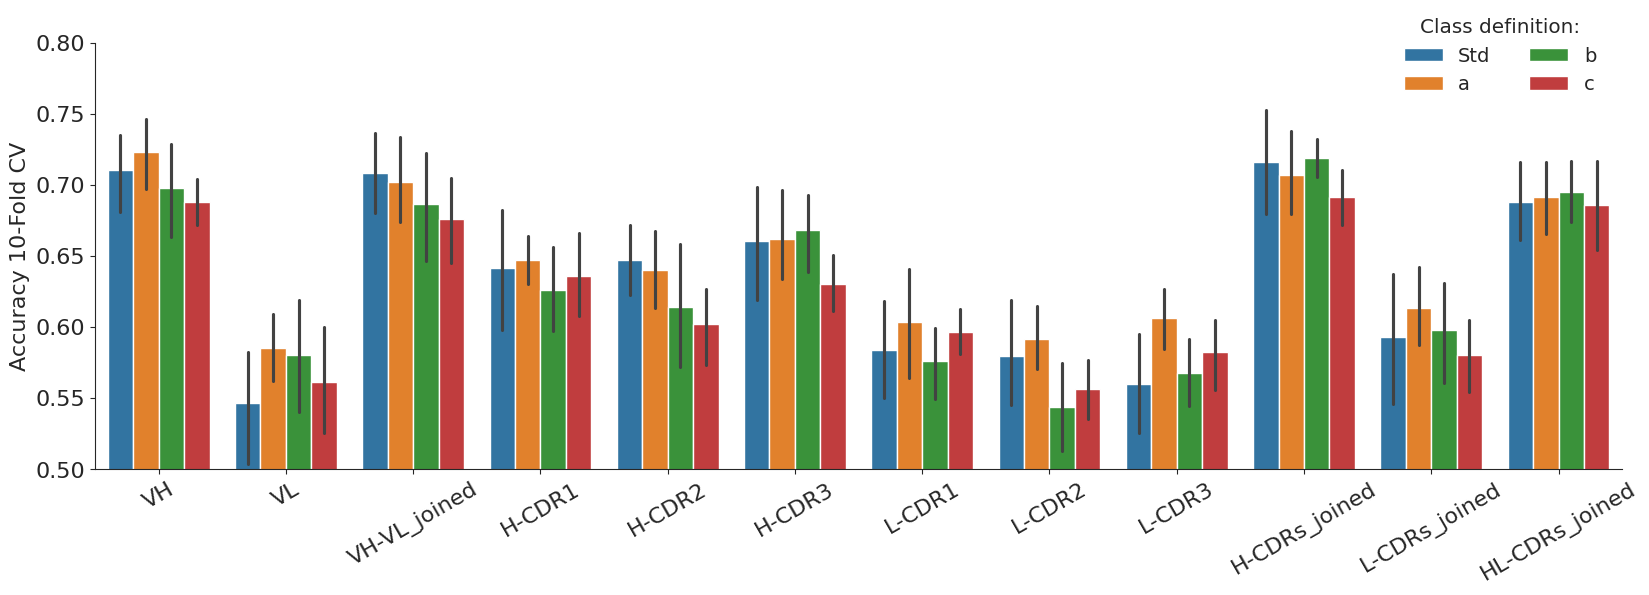

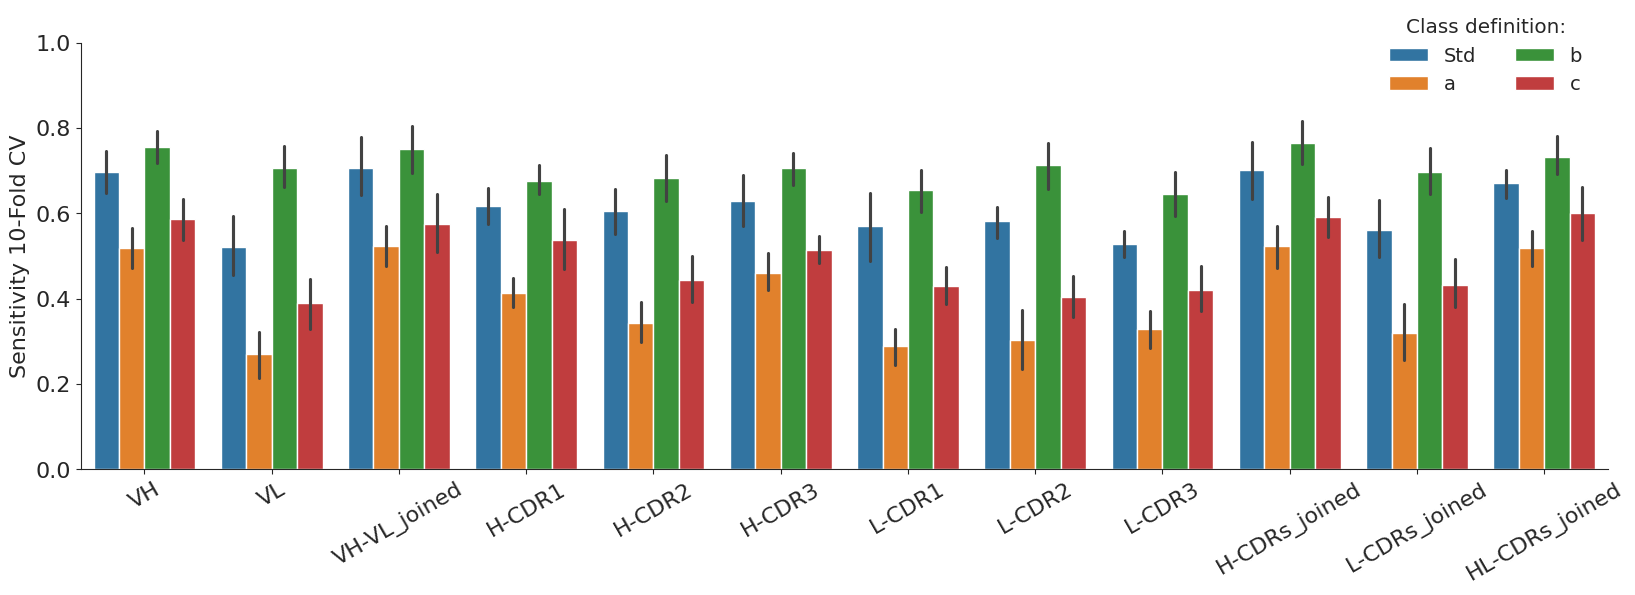

<Figure size 640x480 with 0 Axes>

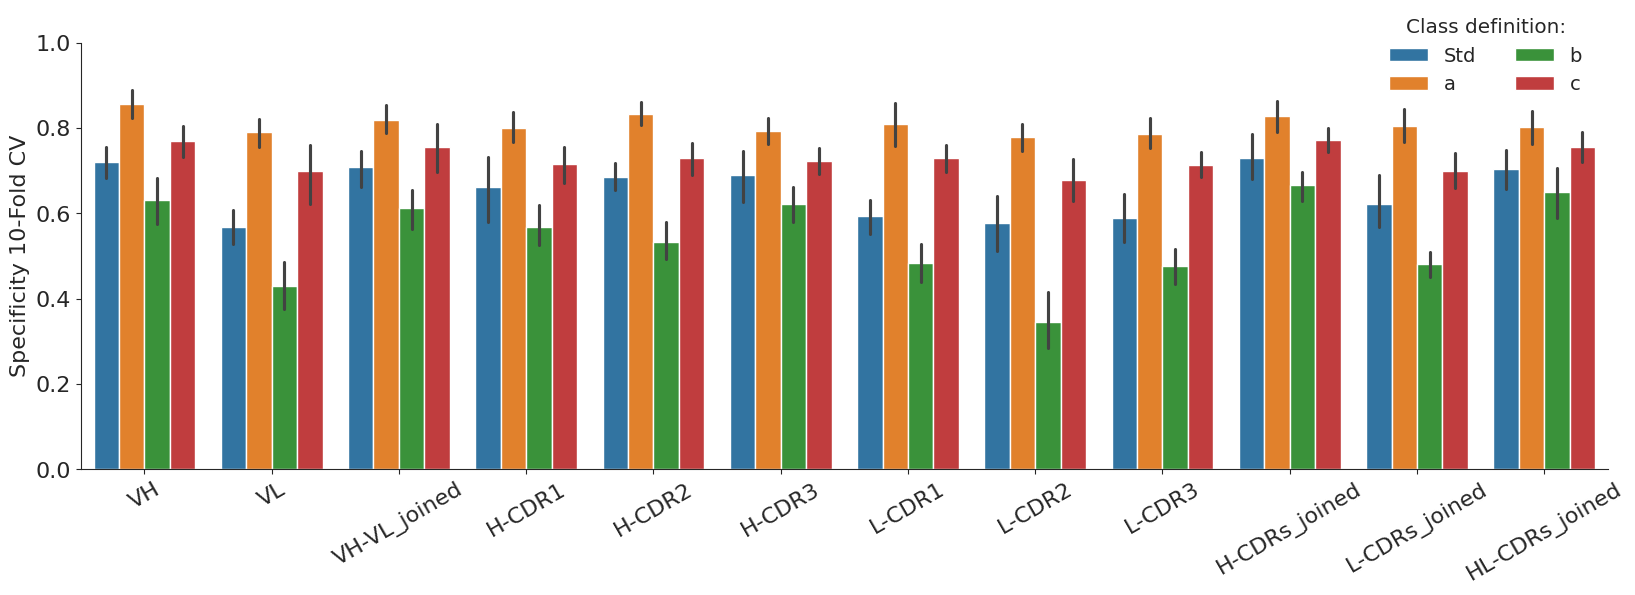

In [45]:
y_lim_1 = [0.5,0,0]
y_lim_2 = [0.8,1,1]
for i, y_axis in enumerate(['accuracy','sensitivity','specificity']):
    plt.figure(1)
    sns.set_style('ticks')
    sns.set_palette(sns.color_palette('tab10'))
    g1 =sns.catplot(data=table_2classes[table_2classes['Embedder']=='esm1v'],
                    x='seq', 
                    y=y_axis,
                    kind='bar', 
                    hue='Class def',
                    hue_order=['Std','a','b','c'],
                    order=['VH', 'VL', 'VH-VL_joined', 'H-CDR1', 'H-CDR2', 'H-CDR3','L-CDR1', 'L-CDR2', 'L-CDR3','H-CDRs_joined', 'L-CDRs_joined','HL-CDRs_joined'],
                    legend_out=False,
                    )

    plt.xticks(rotation=30,ha='center',fontsize=16)
    plt.yticks(fontsize=16)
    plt.ylim(y_lim_1[i],y_lim_2[i])
    #plt.title('ESM 1v',fontsize=16)
    plt.legend(title='Class definition:',loc="upper center", bbox_to_anchor=(0.92, 1.1), ncol=2,frameon=False,borderaxespad=0.5,fontsize=14)
    plt.rcParams['legend.title_fontsize'] = 'x-large'
    g1.fig.set_figwidth(20)
    g1.fig.set_figheight(5)

    if y_axis == 'sensitivity':
        plt.ylabel('Sensitivity 10-Fold CV',fontsize=16)
    else:
        plt.ylabel(y_axis.capitalize() +' 10-Fold CV',fontsize=16)
    plt.xlabel('')
    plt.savefig('./Figures/Bar plots/FigS21_10Fold_CV_'+y_axis+'_ESM1v_robustness_eval.pdf',dpi=300, bbox_inches='tight')



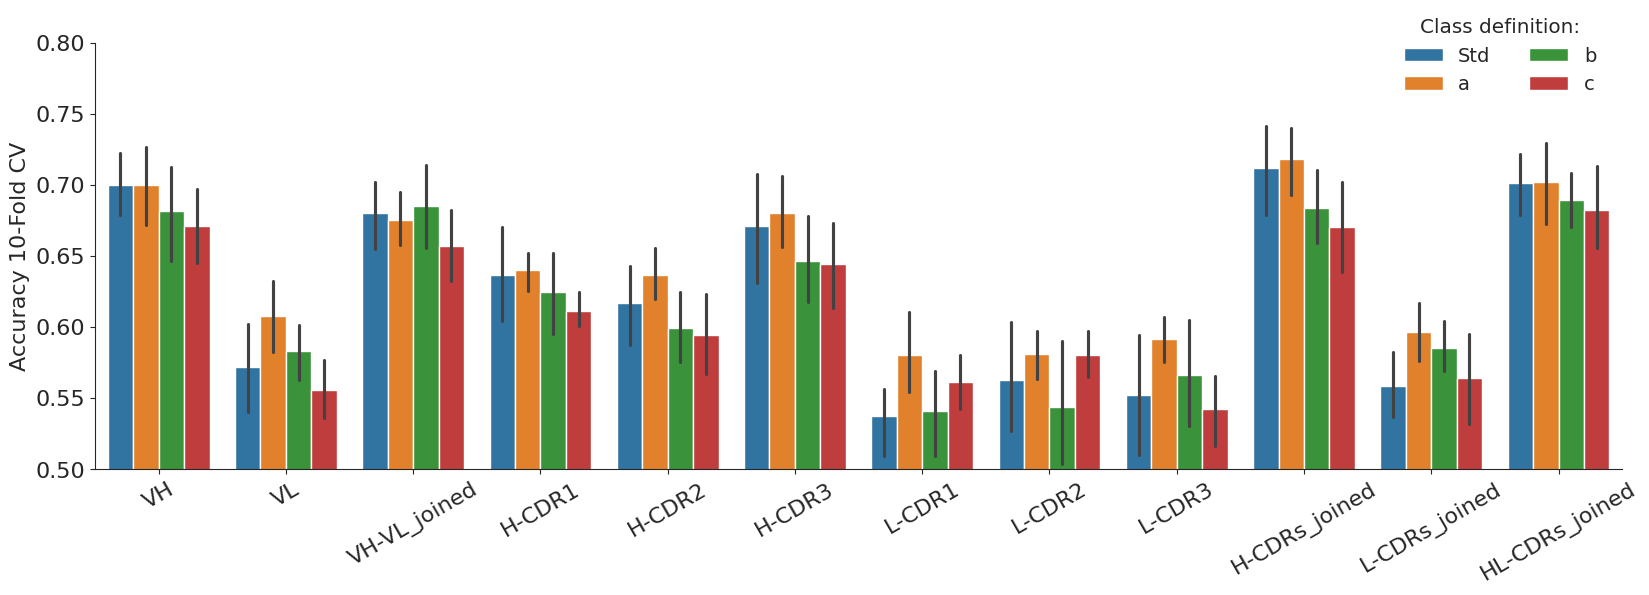

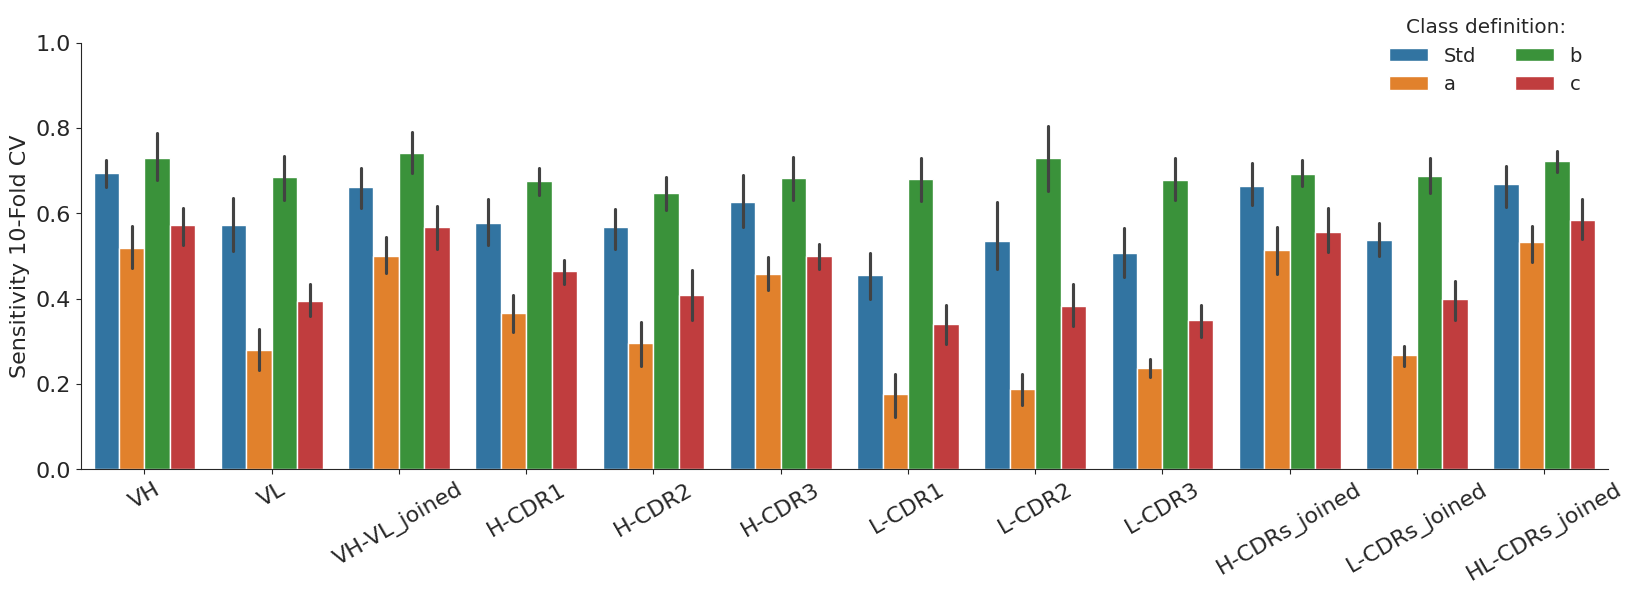

<Figure size 640x480 with 0 Axes>

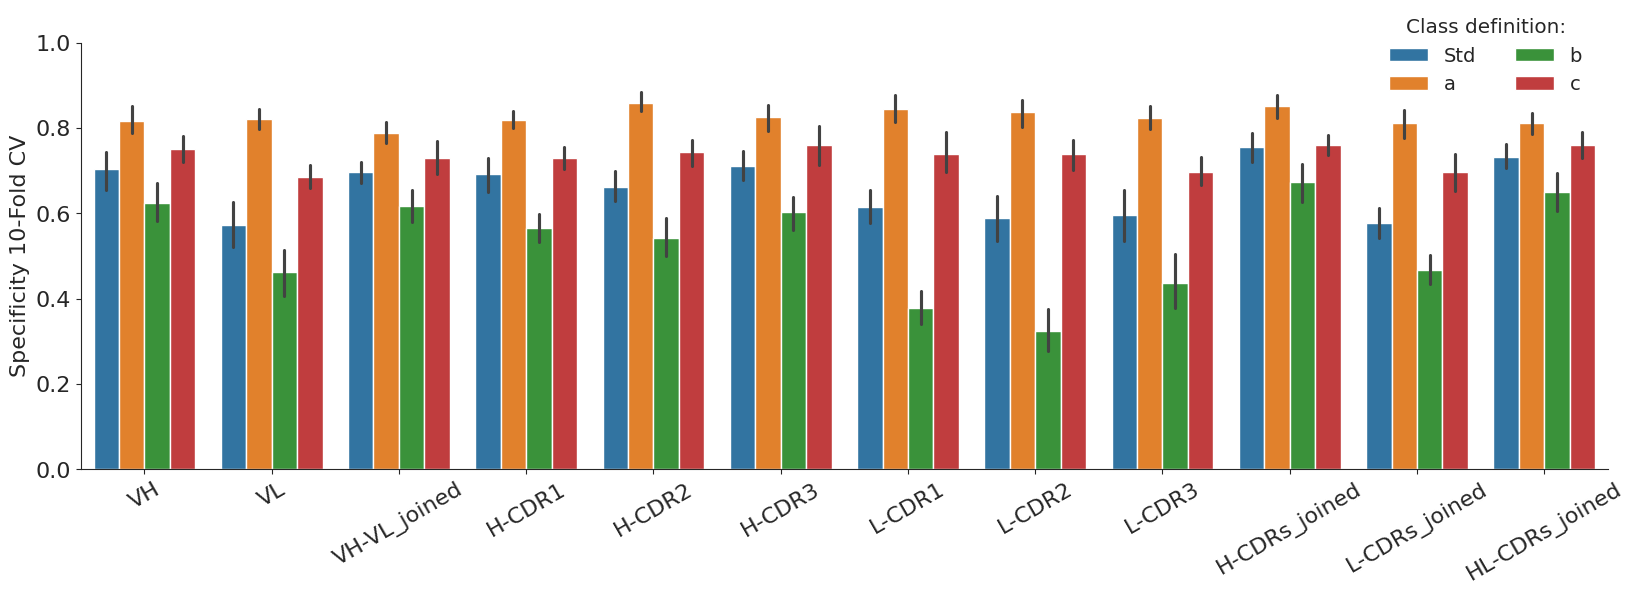

In [46]:
y_lim_1 = [0.5,0,0]
y_lim_2 = [0.8,1,1]
for i, y_axis in enumerate(['accuracy','sensitivity','specificity']):
    plt.figure(1)
    sns.set_style('ticks')
    sns.set_palette(sns.color_palette('tab10'))
    g1 =sns.catplot(data=table_2classes[table_2classes['Embedder']=='desc_all'],
                    x='seq', 
                    y=y_axis,
                    kind='bar', 
                    hue='Class def',
                    hue_order=['Std','a','b','c'],
                    order=['VH', 'VL', 'VH-VL_joined', 'H-CDR1', 'H-CDR2', 'H-CDR3','L-CDR1', 'L-CDR2', 'L-CDR3','H-CDRs_joined', 'L-CDRs_joined','HL-CDRs_joined'],
                    legend_out=False,
                    )

    plt.xticks(rotation=30,ha='center',fontsize=16)
    plt.yticks(fontsize=16)
    plt.ylim(y_lim_1[i],y_lim_2[i])
    #plt.title('ESM 1v',fontsize=16)
    plt.legend(title='Class definition:',loc="upper center", bbox_to_anchor=(0.92, 1.1), ncol=2,frameon=False,borderaxespad=0.5,fontsize=14)
    plt.rcParams['legend.title_fontsize'] = 'x-large'
    g1.fig.set_figwidth(20)
    g1.fig.set_figheight(5)

    if y_axis == 'sensitivity':
        plt.ylabel('Sensitivity 10-Fold CV',fontsize=16)
    else:
        plt.ylabel(y_axis.capitalize() +' 10-Fold CV',fontsize=16)
    plt.xlabel('')
    plt.savefig('./Figures/Bar plots/FigS21_10Fold_CV_'+y_axis+'_desc_all_robustness_eval.pdf',dpi=300, bbox_inches='tight')

